# Maths Lab A — Fourier & Convolution, Hands-On

!!! info "Before you start"
    **Prerequisites:** Ch 3 (Signals, Noise & the Radiometer Equation) · **Appendix · Maths Lab** · **~45 min** · **Intermediate**

This is an **appendix Maths Lab**, not a chapter. It exists to take the two ideas
that do the most work in the whole course — the **Fourier transform** and
**convolution** — and turn them from things you *read about* into things you can
*run, break, and trust*. It deepens [§2 (the Fourier transform)](../docs/math-preliminaries.md)
and [§3 (convolution & the convolution theorem)](../docs/math-preliminaries.md) of the
Mathematical Preliminaries. If those sections felt slippery, this is where they
become muscle memory.

The preliminaries told you *what* the Fourier transform is. They were a little
coy about the **practical FFT details** — the ones that bite every time you write
a spectrometer or an imager and that no equation warns you about:

- how exactly does NumPy's `fft`/`ifft` map onto the textbook integrals — the
  **normalisation**, the **frequency ordering**, the `fftshift` dance?
- what happens when your signal of interest does **not** sit neatly on an FFT
  bin (spoiler: **spectral leakage**), and what **windowing** does about it;
- why **zero-padding** makes a spectrum look smoother without actually buying you
  any new **resolution**.

These are exactly the conventions `jansky.interferometry` uses: open
`src/jansky/interferometry.py` and you will see the
`fftshift(ifft2(ifftshift(...)))` sandwich in `_ift`, and `fft2` in `dirty_image`.
Master them here once and the imaging chapters stop being mysterious.

**What you will be able to do by the end:**

- map `np.fft.fft`/`ifft` and `fftfreq`/`fftshift` onto the forward/inverse FT
  integrals, and read a spectrum with DC in the right place;
- verify the **convolution theorem** numerically and connect it to
  *dirty image = sky ⊛ dirty beam*;
- recognise **spectral leakage**, choose a **window** for the leakage / resolution
  / sidelobe trade-off, and explain why every real spectrometer windows;
- tell the difference between **zero-padding** (interpolation) and genuine
  **resolution** (more data / longer integration).

> This Lab runs **fully offline**: only `numpy`, `scipy`, `matplotlib`, and the
> `jansky` helper package. No archives, no network.

**Used by these chapters:** [Ch 07 · Why Interferometry](07_why_interferometry.ipynb), [Ch 08 · Aperture Synthesis](08_aperture_synthesis.ipynb), [Ch 09 · CLEAN](09_deconvolution_clean.ipynb), [Ch 17 · Coherent Interferometry](17_coherent_interferometry_kraken.ipynb), [Ch 22 · CMB](22_cosmic_microwave_background.ipynb), [Ch 42 · Cosmic Dawn & EoR](42_cosmic_dawn_eor.ipynb).

## Setup

We seed every random generator so the figures are reproducible, and we apply the
course plot style.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows as scipy_windows

from jansky.plotting import use_jansky_style

use_jansky_style()

# One seeded generator for the whole Lab -> reproducible 'randomness'.
rng = np.random.default_rng(31)

print("Offline Maths Lab ready.")
print("numpy", np.__version__)

Offline Maths Lab ready.
numpy 2.4.6


## 2. FFT conventions — how NumPy maps onto the integrals

The Mathematical Preliminaries (§2) write the **forward** and **inverse**
continuous Fourier transform of a signal $g(t)$ in the *ordinary-frequency*
convention the course uses:

$$
G(f) = \int_{-\infty}^{\infty} g(t)\, e^{-i 2\pi f t}\, \mathrm{d}t,
\qquad
g(t) = \int_{-\infty}^{\infty} G(f)\, e^{+i 2\pi f t}\, \mathrm{d}f .
$$

The **Discrete Fourier Transform** that `np.fft.fft` computes is the sampled
version of the forward integral:

$$
G_k = \sum_{n=0}^{N-1} g_n\, e^{-i 2\pi k n / N}.
$$

Three practical facts you must internalise:

1. **Sign.** `fft` carries the $e^{-i2\pi kn/N}$ (minus) — it matches the
   *forward* integral. `ifft` carries the plus sign.
2. **Normalisation.** `fft` has **no** prefactor; `ifft` divides by $N$. So
   `ifft(fft(x)) == x` exactly, but if you want a *physically scaled* spectrum
   (amplitude in the same units as the input) you scale by hand — e.g. divide the
   forward transform by $N$, or by the sample count of a one-sided amplitude
   spectrum.
3. **Frequency ordering.** `fft` returns bins in the order
   $[\,0, +, +, \dots, -, \dots, -\,]$: DC first, then ascending positive
   frequencies, then the negative frequencies wrapped around to the tail.
   `np.fft.fftfreq` hands you the matching frequency axis.

In [2]:
# --- normalisation: ifft(fft(x)) == x, and the N factor lives in ifft ---
x = rng.standard_normal(8)
X = np.fft.fft(x)
roundtrip = np.fft.ifft(X)

print("ifft(fft(x)) == x ?", np.allclose(roundtrip.real, x))
print("fft has no prefactor, ifft divides by N =", x.size)

# Forward DFT, computed by hand, agrees with np.fft.fft:
N = x.size
n = np.arange(N)
manual = np.array([np.sum(x * np.exp(-2j * np.pi * k * n / N)) for k in range(N)])
print("hand-rolled DFT matches np.fft.fft ?", np.allclose(manual, X))

ifft(fft(x)) == x ? True
fft has no prefactor, ifft divides by N = 8
hand-rolled DFT matches np.fft.fft ? True


In [3]:
# --- frequency ordering: fftfreq gives the axis that matches fft's output ---
fs = 1000.0  # sample rate, Hz
Nfreq = 16
freqs = np.fft.fftfreq(Nfreq, d=1 / fs)
print("Raw fftfreq order (Hz):")
print(np.round(freqs, 1))
print("\nNote DC=0 first, then +, then the negatives wrap onto the tail.")
print("Nyquist (the most negative) =", freqs[Nfreq // 2], "Hz")

Raw fftfreq order (Hz):
[   0.    62.5  125.   187.5  250.   312.5  375.   437.5 -500.  -437.5
 -375.  -312.5 -250.  -187.5 -125.   -62.5]

Note DC=0 first, then +, then the negatives wrap onto the tail.
Nyquist (the most negative) = -500.0 Hz


### `fftshift` — put DC in the middle

Because of that wrap-around ordering, "zero frequency" sits at the *start* of the
raw array (and, in 2-D, in the *corner*). That is the natural place for the FFT
maths but the *wrong* place to look at. `np.fft.fftshift` rotates the array so DC
lands in the centre — how you actually want to view a spectrum or an image.
`ifftshift` is its exact inverse (and matters for odd $N$, where the two are not
the same roll).

This is the **shift / transform / inverse-shift sandwich** you will recognise in
`jansky.interferometry._ift`:
`np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(mask)))`.

ifftshift(fftshift(X)) == X ? True


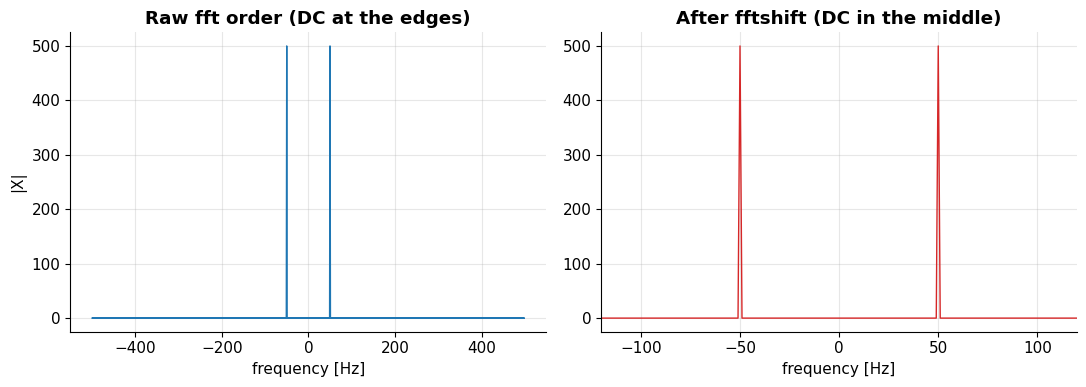

Peak detected at -50.0 Hz (and its mirror at +50.0 Hz).


In [4]:
# A clean 50 Hz tone, sampled at 1 kHz, exactly on an FFT bin.
fs, n_samp = 1000.0, 1000
t = np.arange(n_samp) / fs
tone = np.sin(2 * np.pi * 50.0 * t)

X_raw = np.fft.fft(tone)
f_raw = np.fft.fftfreq(n_samp, d=1 / fs)

X_shift = np.fft.fftshift(X_raw)
f_shift = np.fft.fftshift(f_raw)

# fftshift / ifftshift are exact inverses:
print("ifftshift(fftshift(X)) == X ?", np.allclose(np.fft.ifftshift(X_shift), X_raw))

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
axa.plot(f_raw, np.abs(X_raw), lw=1)
axa.set(title="Raw fft order (DC at the edges)", xlabel="frequency [Hz]", ylabel="|X|")
axb.plot(f_shift, np.abs(X_shift), lw=1, color="#d62728")
axb.set(title="After fftshift (DC in the middle)", xlabel="frequency [Hz]")
axb.set_xlim(-120, 120)
fig.tight_layout()
plt.show()

peak = f_shift[np.argmax(np.abs(X_shift))]
print(f"Peak detected at {peak:+.1f} Hz (and its mirror at {-peak:+.1f} Hz).")

### A known transform pair, numerically: Gaussian ↔ Gaussian

The preliminaries (§8) note two facts worth *seeing*: the FT of a **Gaussian** is
again a Gaussian (no sidelobes), and the FT of a **rect** (box) is a **sinc**.
Let's confirm the Gaussian self-duality on the discrete grid. The continuous
result is that a Gaussian of standard deviation $\sigma_t$ in time transforms to a
Gaussian of standard deviation $\sigma_f = 1/(2\pi\sigma_t)$ in frequency — a wide
pulse has a narrow spectrum and vice-versa.

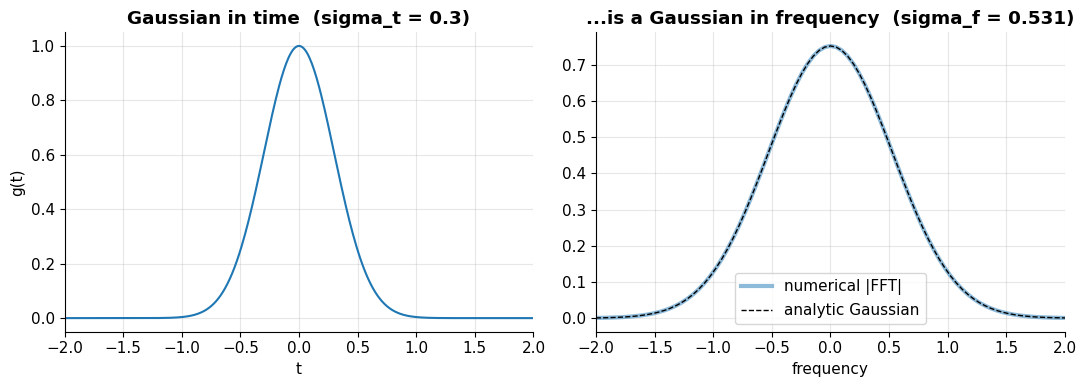

max abs error vs analytic: 2.220446049250313e-16


In [5]:
# Gaussian in 'time', centred at zero, on a symmetric grid.
M = 2048
dt = 0.01
tt = (np.arange(M) - M // 2) * dt
sigma_t = 0.3
g = np.exp(-(tt**2) / (2 * sigma_t**2))

# Forward transform with the shift sandwich so both domains are centred.
G = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(g))) * dt  # dt -> approx the integral
ff = np.fft.fftshift(np.fft.fftfreq(M, d=dt))

# Predicted frequency-domain Gaussian (continuous-FT result):
sigma_f = 1.0 / (2 * np.pi * sigma_t)
G_pred = sigma_t * np.sqrt(2 * np.pi) * np.exp(-(ff**2) / (2 * sigma_f**2))

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
axa.plot(tt, g, color="#1f77b4")
axa.set(title=f"Gaussian in time  (sigma_t = {sigma_t})", xlabel="t", ylabel="g(t)", xlim=(-2, 2))
axb.plot(ff, np.abs(G), lw=3, alpha=0.5, label="numerical |FFT|")
axb.plot(ff, G_pred, "k--", lw=1, label="analytic Gaussian")
axb.set(
    title=f"...is a Gaussian in frequency  (sigma_f = {sigma_f:.3f})",
    xlabel="frequency",
    xlim=(-2, 2),
)
axb.legend()
fig.tight_layout()
plt.show()

print("max abs error vs analytic:", np.max(np.abs(np.abs(G) - G_pred)))

### And rect ↔ sinc

A finite **box** in one domain becomes a **sinc** in the other — the mathematical
ancestor of every sidelobe in the course. (`np.sinc(x) = sin(pi x)/(pi x)`, the
same $\pi$-normalised definition the preliminaries use.)

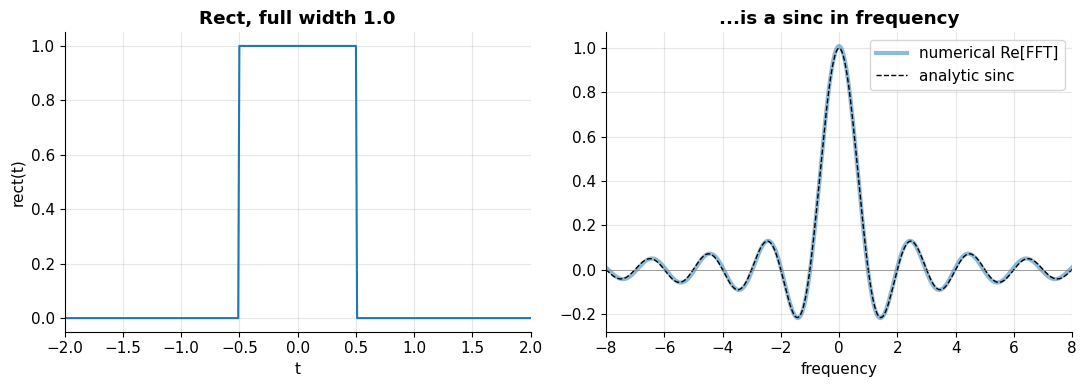

rect <-> sinc max abs error: 0.011820600666078606


In [6]:
# A rect of half-width 'a' centred at zero, on the same grid.
a = 0.5
rect = (np.abs(tt) <= a).astype(float)

R = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rect))) * dt
# Continuous FT of a rect of full width 2a is 2a * sinc(2 a f):
R_pred = 2 * a * np.sinc(2 * a * ff)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
axa.plot(tt, rect, color="#1f77b4")
axa.set(title=f"Rect, full width {2 * a}", xlabel="t", ylabel="rect(t)", xlim=(-2, 2))
axb.plot(ff, R.real, lw=3, alpha=0.5, label="numerical Re[FFT]")
axb.plot(ff, R_pred, "k--", lw=1, label="analytic sinc")
axb.set(title="...is a sinc in frequency", xlabel="frequency", xlim=(-8, 8))
axb.axhline(0, color="grey", lw=0.5)
axb.legend()
fig.tight_layout()
plt.show()

print("rect <-> sinc max abs error:", np.max(np.abs(R.real - R_pred)))

## 3. The convolution theorem — multiply in one domain, smear in the other

Preliminaries §3: **convolution** in one domain is **multiplication** in the
other,

$$
\mathcal{F}\{f \ast h\} = \mathcal{F}\{f\}\cdot \mathcal{F}\{h\}.
$$

This is *the* operational reason the FFT is everywhere: an expensive smearing
becomes a cheap elementwise product. Let's prove it to ourselves by comparing
`np.convolve` (direct, slide-and-sum) against `ifft(fft(f) * fft(h))`.

There is one bookkeeping subtlety: `np.convolve(f, h)` returns a *linear*
convolution of length `len(f)+len(h)-1`, while `ifft(fft·fft)` gives a *circular*
(wrap-around) convolution. They agree exactly **once you zero-pad** both inputs to
at least that combined length so nothing wraps.

In [7]:
f = rng.standard_normal(40)
h = np.exp(-0.5 * ((np.arange(15) - 7) / 2.0) ** 2)  # a little blob kernel

# Direct linear convolution.
direct = np.convolve(f, h)  # length len(f)+len(h)-1
L = f.size + h.size - 1

# Via the FFT: zero-pad both to length L so the circular conv == linear conv.
F = np.fft.fft(f, L)
H = np.fft.fft(h, L)
via_fft = np.fft.ifft(F * H).real

print("np.convolve vs ifft(fft*fft) agree ?", np.allclose(direct, via_fft))
print("max abs difference:", np.max(np.abs(direct - via_fft)))

np.convolve vs ifft(fft*fft) agree ? True
max abs difference: 1.3322676295501878e-15


### Connect it back: *dirty image = sky ⊛ dirty beam*

This is not an abstract identity — it **is** radio imaging (Chapters 8–9). An
interferometer multiplies the true sky's visibilities by a **sampling mask** in
the Fourier plane (it only measures the $(u,v)$ points its baselines reach). By
the convolution theorem, multiplying in the Fourier plane is the same as
**convolving in the image plane** with the transform of that mask — the **dirty
beam** (PSF):

$$
I_\text{dirty} = I_\text{true} \ast B_\text{dirty}.
$$

Here is the *same theorem* in 1-D, using the exact `fftshift` sandwich from
`jansky.interferometry`. We sample only some Fourier components and watch two
point sources smear into the beam.

dirty image == sky (*) dirty beam ? True


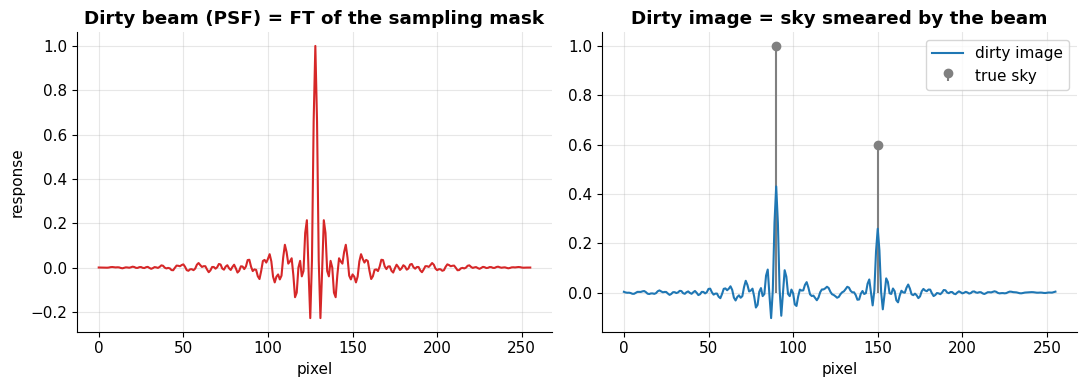

In [8]:
npix = 256
sky = np.zeros(npix)
sky[90] = 1.0  # two point sources
sky[150] = 0.6

# A 'sampling mask' in the (shifted, DC-centred) Fourier plane: keep a band of
# spatial frequencies, with a few holes -> a beam with sidelobes.
mask = np.zeros(npix)
center = npix // 2
mask[center - 60 : center + 60] = 1.0
mask[center - 25 : center - 20] = 0.0  # punch holes -> sidelobes
mask[center + 20 : center + 25] = 0.0


# The jansky way: fftshift(ifft(... * mask) ... ) sandwich.
def ift1(arr):
    return np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(arr))).real


vis = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(sky)))
dirty_image = ift1(vis * mask)
dirty_beam = ift1(mask)
dirty_beam /= np.abs(dirty_beam).max()

# Cross-check: dirty image == sky convolved with the dirty beam (circular).
conv = np.real(np.fft.ifft(np.fft.fft(sky) * np.fft.fft(np.fft.ifftshift(dirty_beam))))
scale = dirty_image.max() / conv.max()
print("dirty image == sky (*) dirty beam ?", np.allclose(dirty_image, conv * scale, atol=1e-9))

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4))
axa.plot(dirty_beam, color="#d62728")
axa.set(title="Dirty beam (PSF) = FT of the sampling mask", xlabel="pixel", ylabel="response")
axb.stem(
    np.where(sky > 0)[0], sky[sky > 0], linefmt="grey", markerfmt="o", basefmt=" ", label="true sky"
)
axb.plot(dirty_image, color="#1f77b4", label="dirty image")
axb.set(title="Dirty image = sky smeared by the beam", xlabel="pixel")
axb.legend()
fig.tight_layout()
plt.show()

## 4. Windowing & spectral leakage — the missing practical piece

Everything so far used tones that landed *exactly* on an FFT bin. Real life is not
so kind. The DFT implicitly assumes your $N$ samples are **one period of a
periodic signal**. If your tone's frequency is not an integer number of cycles in
the window, the assumed periodic extension has a **discontinuity** at the wrap
point — and that discontinuity smears the tone's energy across *many* bins. That
smearing is **spectral leakage**.

FFT bin spacing df = 1.9531 Hz


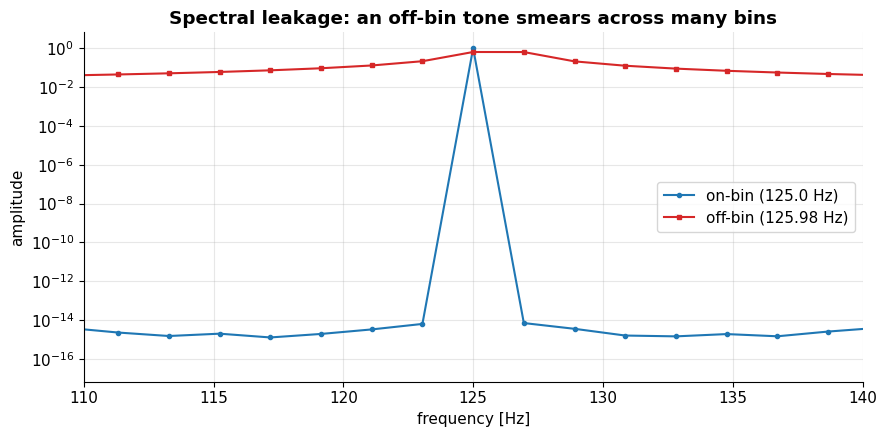

on-bin  leaks into 1 bins above 1e-3
off-bin leaks into 257 bins above 1e-3


In [9]:
fs, N = 1000.0, 512
t = np.arange(N) / fs
df = fs / N  # bin spacing in Hz
print(f"FFT bin spacing df = {df:.4f} Hz")

# Two tones: one ON a bin, one HALFWAY BETWEEN bins (worst case for leakage).
k = 64
f_on = k * df  # exactly on bin k
f_off = (k + 0.5) * df  # halfway between bins k and k+1
on = np.sin(2 * np.pi * f_on * t)
off = np.sin(2 * np.pi * f_off * t)


def amp_spectrum(sig):
    S = np.fft.rfft(sig)
    return np.abs(S) / (N / 2)  # one-sided amplitude scaling


fb = np.fft.rfftfreq(N, d=1 / fs)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(fb, amp_spectrum(on), "o-", ms=3, label=f"on-bin ({f_on:.1f} Hz)")
ax.plot(fb, amp_spectrum(off), "s-", ms=3, color="#d62728", label=f"off-bin ({f_off:.2f} Hz)")
ax.set(
    title="Spectral leakage: an off-bin tone smears across many bins",
    xlabel="frequency [Hz]",
    ylabel="amplitude",
    xlim=(110, 140),
)
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
plt.show()

print("on-bin  leaks into", np.sum(amp_spectrum(on) > 1e-3), "bins above 1e-3")
print("off-bin leaks into", np.sum(amp_spectrum(off) > 1e-3), "bins above 1e-3")

### The fix: window functions

A **window** tapers the samples smoothly to zero at both ends, killing the
wrap-point discontinuity and so suppressing the far-off leakage. The cost is that
the main spectral peak gets a little **wider** and you lose a touch of resolution.
Every window is a point on a three-way trade-off:

- **main-lobe width** (resolution — narrower is better),
- **sidelobe level** (dynamic range — lower is better),
- and the trade between them.

We compare the rectangular window (= no window) against **Hann**, **Hamming**, and
**Blackman** from `scipy.signal.windows`.

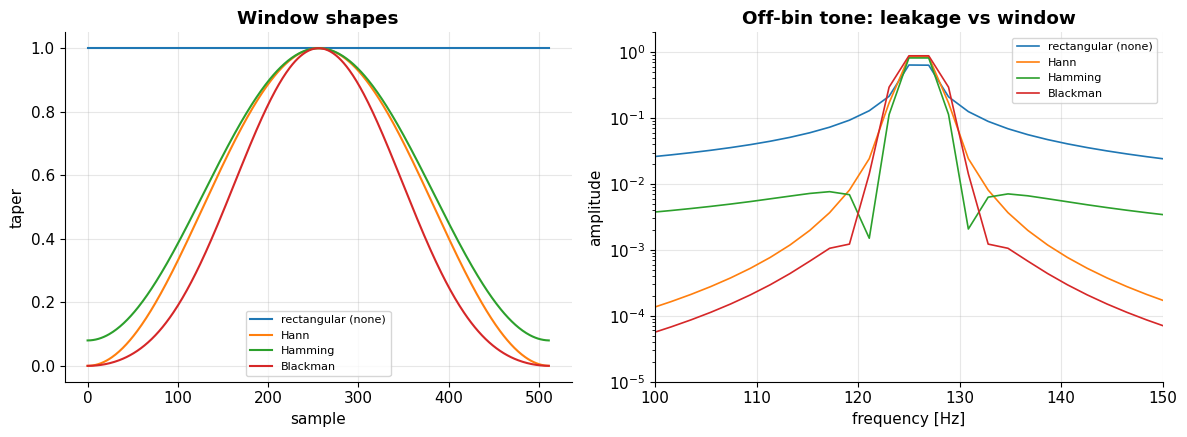

In [10]:
win_funcs = {
    "rectangular (none)": np.ones(N),
    "Hann": scipy_windows.hann(N, sym=False),
    "Hamming": scipy_windows.hamming(N, sym=False),
    "Blackman": scipy_windows.blackman(N, sym=False),
}

fig, (axw, axs) = plt.subplots(1, 2, figsize=(12, 4.5))

for name, w in win_funcs.items():
    axw.plot(w, label=name, lw=1.5)
axw.set(title="Window shapes", xlabel="sample", ylabel="taper")
axw.legend(fontsize=8)

# Spectrum of the off-bin tone through each window (coherent-gain corrected).
for name, w in win_funcs.items():
    cg = w.mean()  # coherent gain -> keep peak amplitude right
    S = np.abs(np.fft.rfft(off * w)) / (N / 2) / cg
    axs.plot(fb, S, lw=1.2, label=name)
axs.set(
    title="Off-bin tone: leakage vs window",
    xlabel="frequency [Hz]",
    ylabel="amplitude",
    xlim=(100, 150),
    ylim=(1e-5, 2),
)
axs.set_yscale("log")
axs.legend(fontsize=8)
fig.tight_layout()
plt.show()

Read the right-hand panel: the **rectangular** window has the *narrowest*
peak but its sidelobes fall off slowly — leakage everywhere. **Hann** and
**Hamming** crush the near sidelobes; **Blackman** crushes them further still, at
the price of the *widest* main lobe. There is no free lunch: you buy dynamic range
with resolution.

Let's read the trade-off off as numbers — the **main-lobe width** (in bins, from
each window's own transform) and the **peak sidelobe level** (in dB).

In [11]:
def window_metrics(w, oversample=32):
    # Transform the window alone, heavily zero-padded, to read its spectral shape.
    Nw = w.size
    W = np.abs(np.fft.rfft(w, Nw * oversample))
    W /= W.max()
    Wdb = 20 * np.log10(W + 1e-12)
    # Main-lobe half-width: first index where it stops descending (the first null).
    descending = np.where(np.diff(W) > 0)[0]
    first_null = descending[0] if descending.size else W.size - 1
    mainlobe_bins = 2 * first_null / oversample  # full width in DFT bins
    peak_sidelobe = Wdb[first_null:].max()  # highest lobe past the null
    return mainlobe_bins, peak_sidelobe


print(f"{'window':<20}{'main-lobe (bins)':>18}{'peak sidelobe (dB)':>22}")
for name, w in win_funcs.items():
    mlb, psl = window_metrics(w)
    print(f"{name:<20}{mlb:>18.2f}{psl:>22.1f}")

window                main-lobe (bins)    peak sidelobe (dB)
rectangular (none)                2.00                 -13.3
Hann                              4.00                 -31.5
Hamming                           4.00                 -42.7
Blackman                          6.00                 -58.1


The pattern is the universal one: rectangular gives the narrowest main lobe
(~2 bins) but the **worst** sidelobes (about $-13$ dB); each smoother window trades
a wider main lobe for dramatically lower sidelobes (Blackman reaches roughly
$-58$ dB).

**This is exactly why spectrometers window.** A radio spectrometer is an FFT
machine, and the sky it stares at contains both faint broadband signal and bright
narrow interferers (a satellite downlink, a local oscillator spur). Without a
window, a single strong off-bin tone would leak its power across the entire band
and bury everything. Channelisers therefore apply a window — often a
**polyphase filter bank**, a windowed FFT on steroids — to keep each channel
clean. You will meet this concretely with the GNU Radio FFT in **Chapter 28**.

## 5. Zero-padding vs resolution — interpolation is not information

A tempting mistake: "my spectrum looks coarse, so I'll zero-pad to get more
points and sharper peaks." **Zero-padding does not add resolution.** It evaluates
the *same* underlying spectrum at *more frequency points* — it **interpolates**
(a sinc interpolation, in fact), drawing a smoother curve through the same
information. The ability to *separate two close tones* is set by how long you
actually observed, not by how many zeros you tack on.

The true frequency resolution is the **Rayleigh limit**

$$
\Delta f \approx \frac{f_s}{N_\text{real}} = \frac{1}{T},
$$

where $T = N_\text{real}/f_s$ is the real observation length. Padding raises the
number of *output* bins but leaves $T$ — and hence $\Delta f$ — untouched.

Real record: N=128, T=0.128 s, true resolution df = 7.81 Hz


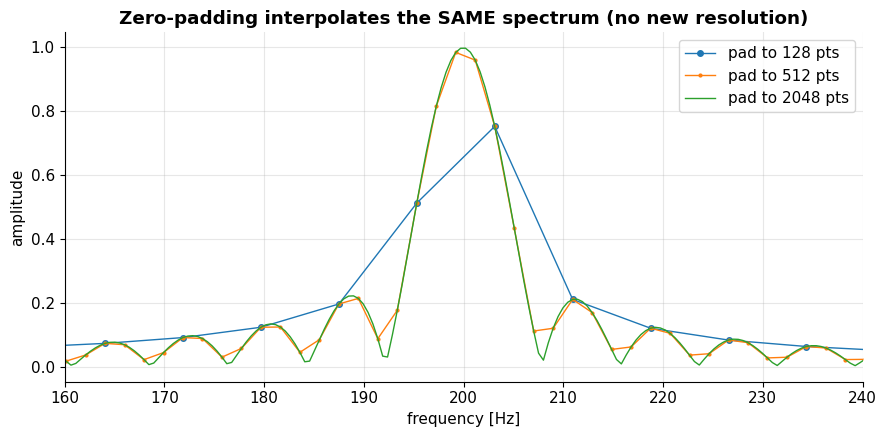

In [12]:
fs = 1000.0
N_real = 128
T = N_real / fs
df_real = 1.0 / T
print(f"Real record: N={N_real}, T={T:.3f} s, true resolution df = {df_real:.2f} Hz")

t = np.arange(N_real) / fs
# A single tone -> zero-padding just interpolates a cleaner sinc envelope.
sig = np.sin(2 * np.pi * 200.0 * t)

fig, ax = plt.subplots(figsize=(9, 4.5))
for pad, style in [(N_real, "o-"), (4 * N_real, ".-"), (16 * N_real, "-")]:
    S = np.abs(np.fft.rfft(sig, pad)) / (N_real / 2)
    fpad = np.fft.rfftfreq(pad, d=1 / fs)
    ax.plot(fpad, S, style, ms=4, lw=1, label=f"pad to {pad} pts")
ax.set(
    title="Zero-padding interpolates the SAME spectrum (no new resolution)",
    xlabel="frequency [Hz]",
    ylabel="amplitude",
    xlim=(160, 240),
)
ax.legend()
fig.tight_layout()
plt.show()

The padded curves trace the *same* sinc envelope — zero-padding just fills
in points between the original samples. The acid test is **two close tones**: if
zero-padding bought real resolution, padding alone would split a blended pair. It
does not.

Longer record: T=1.024 s -> df=0.98 Hz (now < 5 Hz)


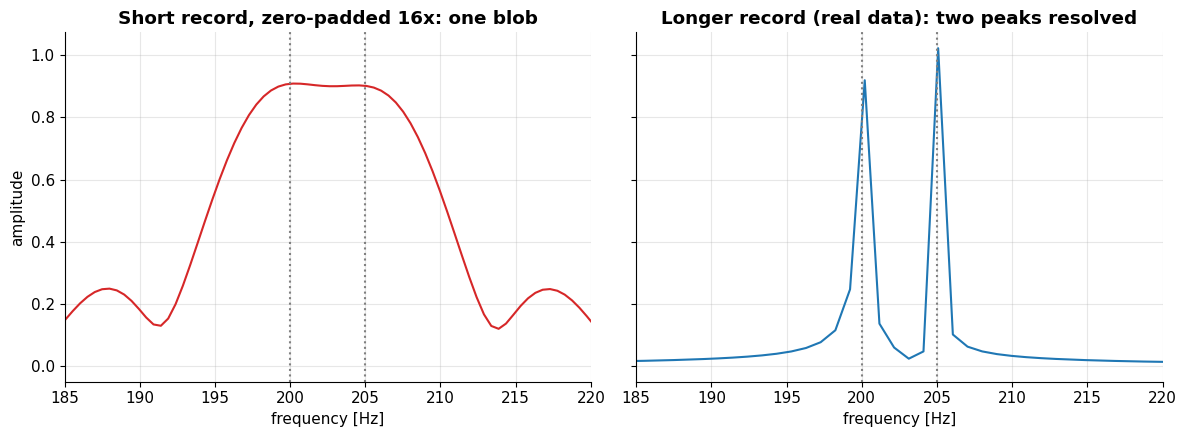

Lesson: padding smooths; only more observing time (larger T) resolves.


In [13]:
# Two tones separated by LESS than the true resolution df_real (~7.8 Hz).
f1, f2 = 200.0, 205.0  # 5 Hz apart < 7.8 Hz -> unresolved in this record length
two = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# Same short record (T fixed), but heavily zero-padded.
pad = 16 * N_real
S_two = np.abs(np.fft.rfft(two, pad)) / (N_real / 2)
f_two = np.fft.rfftfreq(pad, d=1 / fs)

# Now a record that is genuinely LONGER (more real data -> finer df).
N_long = 8 * N_real
t_long = np.arange(N_long) / fs
two_long = np.sin(2 * np.pi * f1 * t_long) + np.sin(2 * np.pi * f2 * t_long)
S_long = np.abs(np.fft.rfft(two_long)) / (N_long / 2)
f_long = np.fft.rfftfreq(N_long, d=1 / fs)
print(f"Longer record: T={N_long / fs:.3f} s -> df={fs / N_long:.2f} Hz (now < 5 Hz)")

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axa.plot(f_two, S_two, color="#d62728")
axa.axvline(f1, color="grey", ls=":")
axa.axvline(f2, color="grey", ls=":")
axa.set(
    title=f"Short record, zero-padded {pad // N_real}x: one blob",
    xlabel="frequency [Hz]",
    ylabel="amplitude",
    xlim=(185, 220),
)
axb.plot(f_long, S_long, color="#1f77b4")
axb.axvline(f1, color="grey", ls=":")
axb.axvline(f2, color="grey", ls=":")
axb.set(
    title="Longer record (real data): two peaks resolved", xlabel="frequency [Hz]", xlim=(185, 220)
)
fig.tight_layout()
plt.show()

print("Lesson: padding smooths; only more observing time (larger T) resolves.")

## Try it yourself

1. **Leakage budget.** Take the off-bin tone from §4 and add a second, much
   *weaker* tone (say $1/1000$ the amplitude) a few bins away. With a rectangular
   window the strong tone's leakage will bury the weak one; show that a Blackman
   window reveals it. This is the satellite-vs-faint-line scenario in miniature.

2. **Parseval's check.** Energy is conserved between domains:
   $\sum_n |x_n|^2 = \frac{1}{N}\sum_k |X_k|^2$. Verify it for a random signal,
   then confirm that applying a window changes the total energy (and why you
   correct for it with the coherent/processing gain).

3. **Build a dirty beam in 2-D.** Use `jansky.interferometry.uv_coverage`,
   `grid_visibilities`, and `dirty_beam` to make a real 2-D PSF, then confirm that
   `dirty_image(sky, sampling)` equals `sky` convolved with that beam — the §3
   identity, now in the form the imaging chapters actually use.

<details><summary>Solution (Exercise 1 — leakage budget)</summary>

Reuse the off-bin tone and amplitude scaling from §4. Add a weak tone `1/1000` as strong, a few bins away. With the rectangular window the strong tone's slowly-falling sidelobes sit *above* the weak peak, so it is buried; the Blackman window pushes sidelobes below ~-58 dB, so the weak tone pokes through. Apply the same coherent-gain correction (`cg = w.mean()`) the §4 window comparison used.

```python
f_strong = (k + 0.5) * df          # the worst-case off-bin tone from §4
f_weak = (k + 8) * df              # a few bins away, on a bin
weak_amp = 1e-3
mix = np.sin(2 * np.pi * f_strong * t) + weak_amp * np.sin(2 * np.pi * f_weak * t)

rect = np.ones(N)
black = scipy_windows.blackman(N, sym=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
for name, w in [("rectangular", rect), ("Blackman", black)]:
    cg = w.mean()
    S = np.abs(np.fft.rfft(mix * w)) / (N / 2) / cg
    ax.plot(fb, S, lw=1.2, label=name)
ax.axvline(f_weak, color="grey", ls=":", label="weak tone")
ax.set(xlabel="frequency [Hz]", ylabel="amplitude", xlim=(110, 200),
       ylim=(1e-6, 2))
ax.set_yscale("log")
ax.legend()
plt.show()
```

Expected: with the rectangular window the weak tone is lost in the strong tone's leakage skirt; with Blackman a clean second peak appears at `f_weak` near the `1e-3` level. This is the bright-satellite-vs-faint-line problem in miniature — dynamic range, not resolution, is what a window buys you here.

</details>

<details><summary>Solution (Exercise 2 — Parseval's check)</summary>

Parseval's theorem for the DFT is `sum |x_n|^2 == (1/N) sum |X_k|^2`, where `X = np.fft.fft(x)`. Verify it on a random signal (reuse the seeded `rng`), then multiply by a Hann window and confirm the total energy drops — the window throws samples away near the edges, which is exactly why you divide by the coherent gain `w.mean()` (or, for power, the processing gain `(w**2).mean()`) to restore a calibrated amplitude.

```python
x = rng.standard_normal(512)
X = np.fft.fft(x)

time_energy = np.sum(np.abs(x) ** 2)
freq_energy = np.sum(np.abs(X) ** 2) / x.size
print("Parseval holds?", np.allclose(time_energy, freq_energy))
print(f"  time domain {time_energy:.4f}  vs  freq domain {freq_energy:.4f}")

w = scipy_windows.hann(x.size, sym=False)
xw = x * w
print("energy after Hann window:", np.sum(np.abs(xw) ** 2))
print("processing gain (w**2).mean() =", np.mean(w ** 2))
print("energy / processing-gain ~ original?",
      np.allclose(np.sum(np.abs(xw) ** 2) / np.mean(w ** 2),
                  time_energy, rtol=0.1))
```

Expected: the two energies match to machine precision (`Parseval holds? True`). The windowed signal carries less total energy (Hann's processing gain is `0.375`), and dividing by `(w**2).mean()` recovers the original energy to within the statistical scatter — the bookkeeping that keeps windowed spectra physically scaled.

</details>

In [14]:
# Scratch space for the exercises.
from jansky import interferometry

# Exercise 3 starter: a tiny array, its sampling, and its dirty beam.
ant = np.array([[0.0, 0.0], [120.0, 30.0], [-80.0, 90.0], [60.0, -110.0]])
uv = interferometry.uv_coverage(ant, declination=np.deg2rad(80))
sampling = interferometry.grid_visibilities(uv, npix=128)
beam2d = interferometry.dirty_beam(sampling)
print(
    "2-D dirty beam shape:",
    beam2d.shape,
    " peak at centre =",
    np.unravel_index(np.argmax(beam2d), beam2d.shape),
)
# ... your turn: form dirty_image of a two-point sky and compare to a convolution.

2-D dirty beam shape: (128, 128)  peak at centre = (np.int64(64), np.int64(64))


<details><summary>Solution (Exercise 3 — 2-D dirty beam)</summary>

Pick up from the starter cell's `sampling` and `beam2d`. Build a two-point `sky`, form its dirty image with `interferometry.dirty_image(sky, sampling)`, and convolve the *same* sky with `beam2d` using the chapter's `ifftshift`/`fft2` sandwich. `dirty_beam` returns a peak-normalised beam, so — exactly as in the 1-D §3 cell — the two agree up to a single scalar found from `dirty_image.max() / conv.max()`.

```python
sky = np.zeros((128, 128))
sky[40, 50] = 1.0      # two point sources
sky[80, 70] = 0.6

di = interferometry.dirty_image(sky, sampling)

# Convolve the sky with the (centred) dirty beam, same sandwich as elsewhere:
conv = np.fft.ifft2(
    np.fft.fft2(sky) * np.fft.fft2(np.fft.ifftshift(beam2d))
).real
scale = di.max() / conv.max()      # beam2d is peak-normalised -> one scalar
print("dirty_image == sky (*) dirty_beam ?",
      np.allclose(di, conv * scale, atol=1e-9))

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 4.5))
axa.imshow(beam2d, origin="lower", cmap="cividis")
axa.set(title="2-D dirty beam (PSF)")
axb.imshow(di, origin="lower", cmap="cividis")
axb.set(title="Dirty image: two points smeared by the beam")
fig.tight_layout()
plt.show()
```

Expected: `dirty_image == sky (*) dirty_beam ? True`. The two point sources each appear convolved with the same PSF (sidelobes and all) — the §3 convolution theorem in the exact 2-D form the aperture-synthesis chapters use: *dirty image = sky ⊛ dirty beam*.

</details>

## Recap & where this goes

You now have the **practical** Fourier toolkit, not just the equations:

- `fft`/`ifft` map onto the forward/inverse integrals — **minus sign forward**,
  **$N$ in the inverse**; `fftfreq` gives the axis; `fftshift`/`ifftshift` put DC
  where you want it. This is the `_ift` sandwich in `jansky.interferometry`.
- The **convolution theorem** is *dirty image = sky ⊛ dirty beam* — multiply in
  the Fourier plane, smear in the image plane.
- **Leakage** is what an off-bin tone does to a naive FFT; **windowing**
  (Hann/Hamming/Blackman) trades main-lobe width for sidelobe suppression, which
  is why every spectrometer windows.
- **Zero-padding interpolates**; only more observing time **resolves**.

Where to take it next:

- **Chapter 5 — SDR basics & spectra**: you build real spectra from sampled
  voltages; windowing and bin spacing stop being abstract.
- **Chapter 8 — Aperture synthesis** (van Cittert–Zernike): the 2-D version of
  §2–§3 — visibilities *are* the FT of the sky, sampled on the $(u,v)$ plane.
- **Chapter 28 — GNU Radio FFT**: the windowed FFT / polyphase channeliser running
  live on a software-defined radio.

Onward — the maths is no longer something that happens to you.

<!-- glossary-footer -->

---

## 📖 Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Aperture synthesis](../docs/glossary.md#aperture-synthesis) ·
[Beam](../docs/glossary.md#beam) ·
[CLEAN](../docs/glossary.md#clean) ·
[CMB](../docs/glossary.md#cmb) ·
[Cosmic dawn](../docs/glossary.md#cosmic-dawn) ·
[Dirty beam / dirty image](../docs/glossary.md#dirty-beam-dirty-image) ·
[Dynamic range](../docs/glossary.md#dynamic-range) ·
[Epoch of Reionization](../docs/glossary.md#epoch-of-reionization) ·
[Gain](../docs/glossary.md#gain) ·
[GNU Radio](../docs/glossary.md#gnu-radio) ·
[Radiometer equation](../docs/glossary.md#radiometer-equation) ·
[Sidelobe](../docs/glossary.md#sidelobe)
